In [1]:
from pathlib import Path 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [2]:
PROCESSED_PATH = Path("../data/processed")
FIGURES_PATH = Path("../reports/figures")

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
orders = pd.read_csv(PROCESSED_PATH / "orders_enriched.csv", parse_dates=["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date", "purchase_month",])
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_revenue,freight_value,items_count,sellers_count,products_count,payment_value,payment_records,installments_max,payment_types_count,review_score,reviews_count,purchase_month,delivery_days,delay_days,is_late,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.00,1.00,1.00,38.71,3.00,1.00,2.00,4.00,1.00,2017-10-01,8.44,-7.11,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.00,1.00,1.00,141.46,1.00,1.00,1.00,4.00,1.00,2018-07-01,13.78,-5.36,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.00,1.00,1.00,179.12,1.00,3.00,1.00,5.00,1.00,2018-08-01,9.39,-17.25,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.00,1.00,1.00,72.20,1.00,1.00,1.00,5.00,1.00,2017-11-01,13.21,-12.98,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.00,1.00,1.00,28.62,1.00,1.00,1.00,5.00,1.00,2018-02-01,2.87,-9.24,False,False


In [4]:
orders.shape

(99441, 28)

In [5]:
orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'product_revenue',
 'freight_value',
 'items_count',
 'sellers_count',
 'products_count',
 'payment_value',
 'payment_records',
 'installments_max',
 'payment_types_count',
 'review_score',
 'reviews_count',
 'purchase_month',
 'delivery_days',
 'delay_days',
 'is_late',
 'is_canceled']

In [8]:
delivered = orders[orders["order_status"] == "delivered"].copy()
delivered = delivered.dropna(subset=["customer_unique_id", "order_purchase_timestamp", ])
print("Quantity of delivered orders: ", len(delivered))
print("Quantity of unique clients: ", delivered["customer_unique_id"].nunique())

Quantity of delivered orders:  96478
Quantity of unique clients:  93358


In [10]:
delivered["order_month"] = delivered["order_purchase_timestamp"].dt.to_period("M")
delivered[["order_purchase_timestamp", "order_month"]].head()

,order_purchase_timestamp,order_month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


In [12]:
first_purchase = delivered.groupby("customer_unique_id")["order_month"].min().rename("cohort_month")
delivered = delivered.merge(first_purchase, on="customer_unique_id", how="left", validate="many_to_one")
delivered[["customer_unique_id", "order_month", "cohort_month",]].head()

,customer_unique_id,order_month,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02


In [15]:
def month_difference(later_month, earlier_month):
    return ((later_month.dt.year - earlier_month.dt.year)*12 + later_month.dt.month - earlier_month.dt.month)

delivered["cohort_index"] = month_difference(delivered["order_month"], delivered["cohort_month"])
delivered[["customer_unique_id", "order_month", "cohort_month", "cohort_index"]].head()

,customer_unique_id,order_month,cohort_month,cohort_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0


cohort_index = 0 - месяц первой покупки
cohort_index = 1 - следующий месяц
cohort_index = 2 - через два месяца
...

In [16]:
delivered["cohort_index"].min()

0

We haven't negative value

In [17]:
cohort_counts = delivered.groupby(["cohort_month", "cohort_index"])["customer_unique_id"].nunique().reset_index(name="customers_count")
cohort_counts.head()

,cohort_month,cohort_index,customers_count
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1


In [20]:
cohort_matrix = cohort_counts.pivot(index="cohort_month", columns="cohort_index", values="customers_count")
cohort_matrix = cohort_matrix.fillna(0)
cohort_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,262.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,2.00,2.00
2016-12,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,717.00,2.00,2.00,1.00,3.00,1.00,3.00,1.00,1.00,0.00,3.00,1.00,5.00,3.00,1.00,1.00,2.00,3.00,1.00,0.00
2017-02,1628.00,3.00,5.00,2.00,7.00,2.00,4.00,3.00,2.00,3.00,2.00,5.00,2.00,3.00,2.00,1.00,1.00,3.00,0.00,0.00


In [23]:
cohort_sizes = cohort_matrix[0]
retention_matrix = cohort_matrix.div(cohort_sizes, axis=0)
retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01
2016-12,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [25]:
last_order_month = delivered["order_month"].max()
print("Last month of data: ", last_order_month)

Last month of data:  2018-08


In [29]:
for cohort_month in retention_matrix.index:
    max_observed_index = (last_order_month.year - cohort_month.year)*12 + last_order_month.month - cohort_month.month
    future_columns = [column for column in retention_matrix.columns if column > max_observed_index]
    retention_matrix.loc[cohort_month, future_columns] = np.nan

regular_retention = retention_matrix.loc[(retention_matrix.index >= pd.Period("2017-01", freq="M")) & (retention_matrix.index <= pd.Period("2018-08", freq="M"))].copy()
regular_retention_12 = regular_retention.loc[:, 0:11]

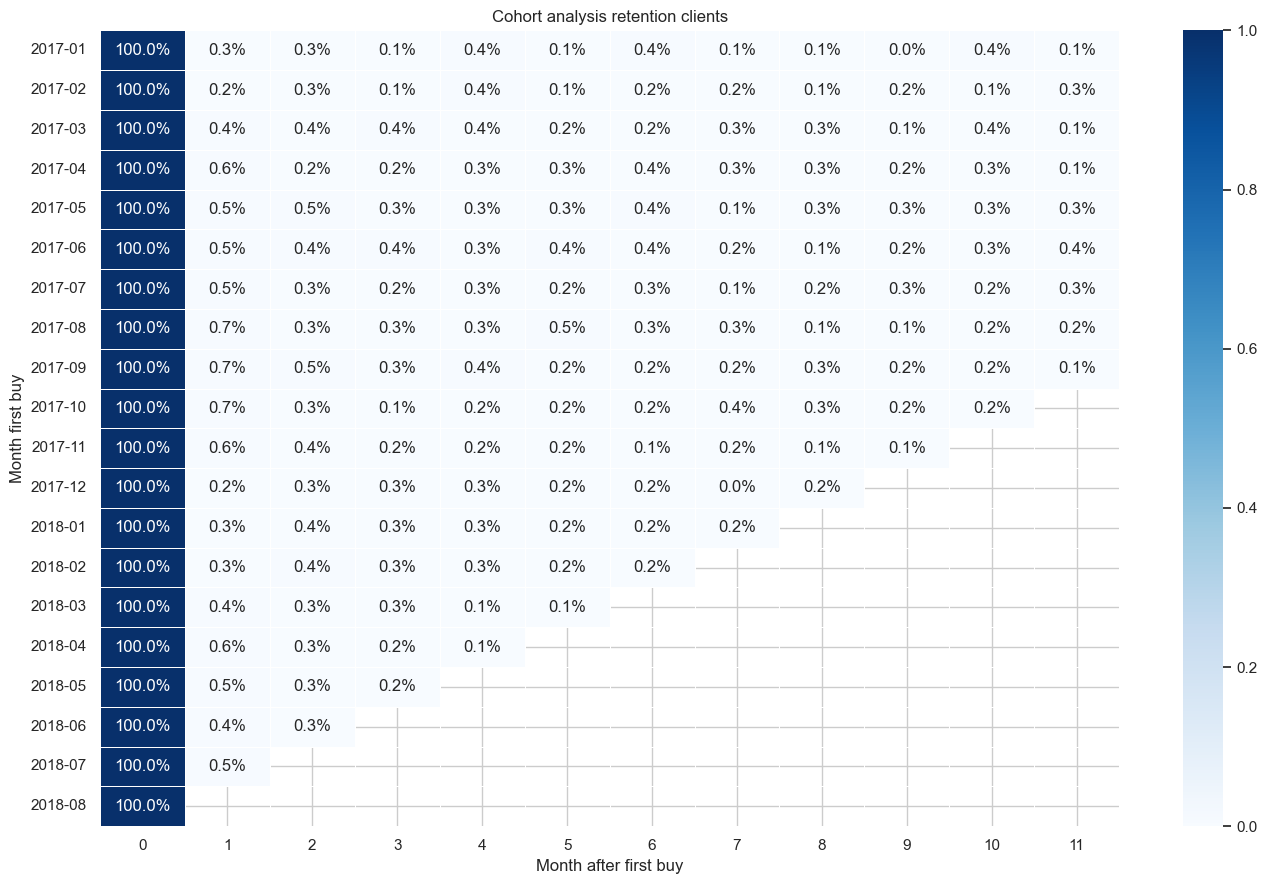

In [30]:
plt.figure(figsize=(14, 9))

sns.heatmap(
    regular_retention_12,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    mask=regular_retention_12.isna(),
    linewidths=0.5
)

plt.title("Cohort analysis retention clients")
plt.xlabel("Month after first buy")
plt.ylabel("Month first buy")
plt.tight_layout()

In [31]:
plt.savefig(
    FIGURES_PATH / "retention_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [33]:
customer_order_counts = delivered.groupby("customer_unique_id")["order_id"].nunique()
customer_order_counts.value_counts().sort_index().head(10)

order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [34]:
repeat_customers_count = (customer_order_counts > 1).sum()
repeat_customers_count

np.int64(2801)

In [41]:
repeat_customer_rate = (customer_order_counts > 1).mean()
print(f"Part of clients with repeat buyers: " f"{repeat_customer_rate:.2%}")
month_1_retention = regular_retention[1].mean()
print(f"Mean retention after one month: " f"{month_1_retention:.2%}")
month_3_retention = regular_retention[3].mean()
print(f"Mean retention after three month: " f"{month_3_retention:.2%}")
month_6_retention = regular_retention[6].mean()
print(f"Mean retention after six month: " f"{month_6_retention:.2%}")

Part of clients with repeat buyers: 3.00%
Mean retention after one month: 0.48%
Mean retention after three month: 0.25%
Mean retention after six month: 0.26%


In [42]:
best_month_1_cohorts = regular_retention[1].dropna().sort_values(ascending=False).head(5)
best_month_1_cohorts

cohort_month
2017-10   0.01
2017-09   0.01
2017-08   0.01
2017-04   0.01
2018-04   0.01
Freq: M, Name: 1, dtype: float64

In [43]:
worth_month_1_cohorts = regular_retention[1].dropna().sort_values().head(5)
worth_month_1_cohorts

cohort_month
2017-02   0.00
2017-12   0.00
2017-01   0.00
2018-01   0.00
2018-02   0.00
Freq: M, Name: 1, dtype: float64

In [45]:
cohort_comparison = pd.DataFrame({
    "cohort_size": cohort_sizes,
    "month_1_retention":retention_matrix.get(1),
    "month_3_retention": retention_matrix.get(3),
    "month_6_retention" : retention_matrix.get(6),
})

cohort_comparison.loc[pd.Period("2017-01", freq="M"): pd.Period("2018-08", freq="M")]


,cohort_size,month_1_retention,month_3_retention,month_6_retention
cohort_month,,,,
2017-01,717.00,0.00,0.00,0.00
2017-02,1628.00,0.00,0.00,0.00
2017-03,2503.00,0.00,0.00,0.00
2017-04,2256.00,0.01,0.00,0.00
2017-05,3451.00,0.00,0.00,0.00
2017-06,3037.00,0.00,0.00,0.00
2017-07,3752.00,0.01,0.00,0.00
2017-08,4057.00,0.01,0.00,0.00
2017-09,4004.00,0.01,0.00,0.00


In [47]:
retention_to_save =  retention_matrix.copy()
retention_to_save.index = retention_to_save.index.astype(str)
retention_to_save.to_csv(PROCESSED_PATH / "cohort_retention.csv")
assert delivered["cohort_index"].min() == 0

In [48]:
assert np.allclose(retention_matrix[0].dropna(), 1.0)

In [49]:
assert (retention_matrix.drop(columns=0).max().max() <= 1)

## Выводы третьего этапа

1. Клиенты распределены по когортам на основании месяца их первой доставленной покупки.

2. Для каждой когорты рассчитан retention — доля клиентов, совершивших повторную покупку через определённое количество месяцев.

3. Доля клиентов, совершивших более одной покупки, составила **3%**.

4. Средний retention через один месяц составил **0.48%**, через три месяца — **0.25%**, через шесть месяцев — **0.26%**.

5. Большинство клиентов не совершает повторную покупку в следующем месяце, что указывает на низкую частоту повторных заказов в доступном периоде наблюдения.

6. Наиболее высокий retention через один месяц наблюдался у когорт **2017-10, 2017-09, 2017-08, 2017-04, 2018-04**, составив **0.01**.

7. Последние когорты имеют более короткий период наблюдения. Недоступные будущие месяцы отмечены как пропуски и не интерпретируются как нулевой retention.

8. Результаты не позволяют установить причины низкого retention. Для объяснения необходимы дополнительные данные о маркетинге, поведении пользователей и ассортименте.

9. На следующем этапе клиенты будут сегментированы с помощью RFM-анализа по давности, частоте и стоимости покупок.

In [50]:
from pathlib import Path
import pandas as pd

file_path = Path(
    "../data/processed/cohort_retention.csv"
)

retention_wide = pd.read_csv(file_path)

retention_wide.head()

,cohort_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
0,2016-09,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2016-10,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01
2,2016-12,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
4,2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


In [51]:
retention_wide = retention_wide.rename(
    columns={
        retention_wide.columns[0]: "cohort_month"
    }
)

cohort_retention_long = retention_wide.melt(
    id_vars="cohort_month",
    var_name="cohort_index",
    value_name="retention"
)

cohort_retention_long["cohort_index"] = pd.to_numeric(
    cohort_retention_long["cohort_index"],
    errors="coerce"
)

cohort_retention_long["retention"] = pd.to_numeric(
    cohort_retention_long["retention"],
    errors="coerce"
)

cohort_retention_long = cohort_retention_long.dropna(
    subset=["cohort_index", "retention"]
)

cohort_retention_long["cohort_index"] = (
    cohort_retention_long["cohort_index"].astype(int)
)

cohort_retention_long.head(10)

,cohort_month,cohort_index,retention
0,2016-09,0,1.00
1,2016-10,0,1.00
2,2016-12,0,1.00
3,2017-01,0,1.00
4,2017-02,0,1.00
5,2017-03,0,1.00
6,2017-04,0,1.00
7,2017-05,0,1.00
8,2017-06,0,1.00
9,2017-07,0,1.00


In [52]:
output_path = Path(
    "../data/processed/cohort_retention_long.csv"
)

cohort_retention_long.to_csv(
    output_path,
    index=False
)

print("Файл сохранён:", output_path)

Файл сохранён: ../data/processed/cohort_retention_long.csv
